# 03 - Modelagem supervisionada

Compara três classificadores usando as mesmas seis features do projeto de referência. O pré-processamento fica dentro do Pipeline do Scikit-learn, evitando que imputação, escala e encoding aprendam com o holdout.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from src.modeling import (
    FEATURES, TARGET, carregar_dataset, construir_pipeline,
    modelos_candidatos, nomes_das_features
)

sns.set_theme(style="whitegrid")
df = carregar_dataset()
treino = df[df["ano"] == 2023].copy()
teste = df[df["ano"] == 2024].copy()
X_train, y_train = treino[FEATURES], treino[TARGET]
X_test, y_test = teste[FEATURES], teste[TARGET]
print(f"Treino 2023: {len(treino):,} | Holdout 2024: {len(teste):,}")
print("Features:", FEATURES)

Treino 2023: 5,302 | Holdout 2024: 5,352
Features: ['media_portugues', 'meta_2025', 'meta_uf_2025', 'taxa_media_uf_loo', 'sigla_uf', 'regiao']


## Split temporal e tratamento de leakage

- Treino: 2023; teste final: 2024.
- O holdout não participa do ajuste nem da escolha dos hiperparâmetros.
- Taxa, gap, status, nível e proporções SAEB ficam fora de X.
- A média estadual é leave-one-out.
- Imputação, padronização e one-hot encoding são ajustados dentro de cada pipeline.

In [2]:
def medir(nome, modelo):
    previsto = modelo.predict(X_test)
    prob = modelo.predict_proba(X_test)[:, 1]
    return {
        "modelo": nome,
        "acuracia": accuracy_score(y_test, previsto),
        "precisao": precision_score(y_test, previsto, zero_division=0),
        "recall": recall_score(y_test, previsto, zero_division=0),
        "f1": f1_score(y_test, previsto, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob),
        "pr_auc": average_precision_score(y_test, prob),
    }

ajustados, resultados = {}, []
for nome, estimador in modelos_candidatos().items():
    pipeline = construir_pipeline(estimador)
    pipeline.fit(X_train, y_train)
    ajustados[nome] = pipeline
    resultados.append(medir(nome, pipeline))
comparacao = pd.DataFrame(resultados).sort_values("roc_auc", ascending=False)
display(comparacao.round(3))

,modelo,acuracia,precisao,recall,f1,roc_auc,pr_auc
0,Regressão Logística,0.717,0.808,0.457,0.584,0.819,0.788
2,Gradient Boosting,0.650,0.720,0.318,0.441,0.815,0.734
1,Random Forest,0.586,0.557,0.226,0.322,0.710,0.613


## Escolha e otimização

A Regressão Logística é escolhida pelo melhor equilíbrio entre ROC-AUC, F1, estabilidade e interpretação. O GridSearchCV usa apenas 2023; 2024 permanece como teste final.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
busca = GridSearchCV(
    construir_pipeline(),
    {"modelo__C": [0.01, 0.1, 1.0, 10.0]},
    scoring="f1", cv=cv, n_jobs=-1, refit=True,
)
busca.fit(X_train, y_train)
modelo_final = busca.best_estimator_
metricas_finais = medir("Regressão Logística otimizada", modelo_final)
print("Melhor configuração:", busca.best_params_)
display(pd.DataFrame([metricas_finais]).round(3))

Melhor configuração: {'modelo__C': 1.0}


,modelo,acuracia,precisao,recall,f1,roc_auc,pr_auc
0,Regressão Logística otimizada,0.717,0.808,0.457,0.584,0.819,0.788


## Avaliação final

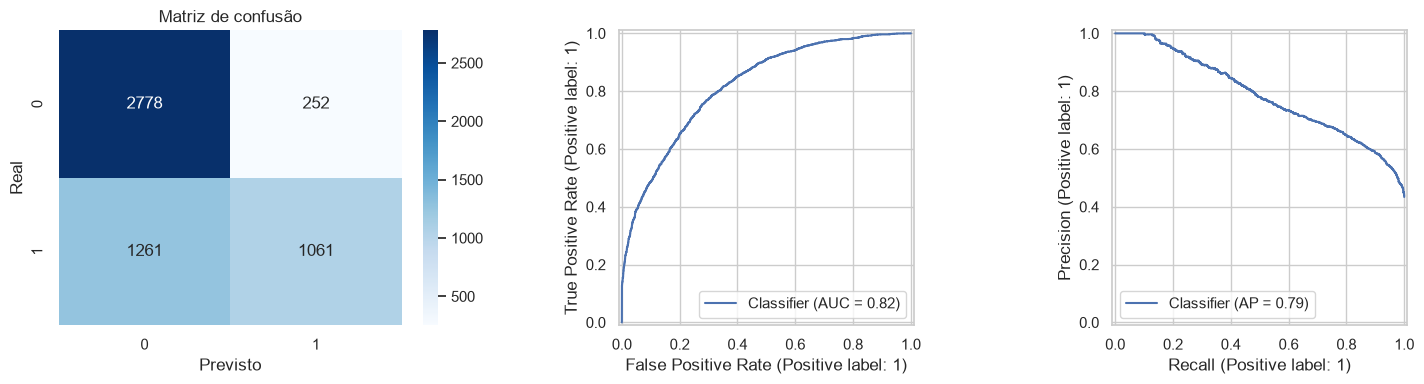

In [4]:
y_pred = modelo_final.predict(X_test)
y_prob = modelo_final.predict_proba(X_test)[:, 1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d",
            cmap="Blues", ax=axes[0])
axes[0].set(title="Matriz de confusão", xlabel="Previsto", ylabel="Real")
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2])
plt.tight_layout()
plt.show()

## Interpretabilidade

,variavel,coeficiente,importancia_abs
0,media_portugues,5.416,5.416
21,sigla_uf_RN,2.570,2.570
15,sigla_uf_PA,2.161,2.161
10,sigla_uf_GO,1.970,1.970
13,sigla_uf_MS,-1.795,1.795
32,regiao_Sul,1.659,1.659
27,sigla_uf_TO,-1.639,1.639
5,sigla_uf_AM,1.448,1.448
22,sigla_uf_RO,-1.379,1.379
9,sigla_uf_ES,1.292,1.292


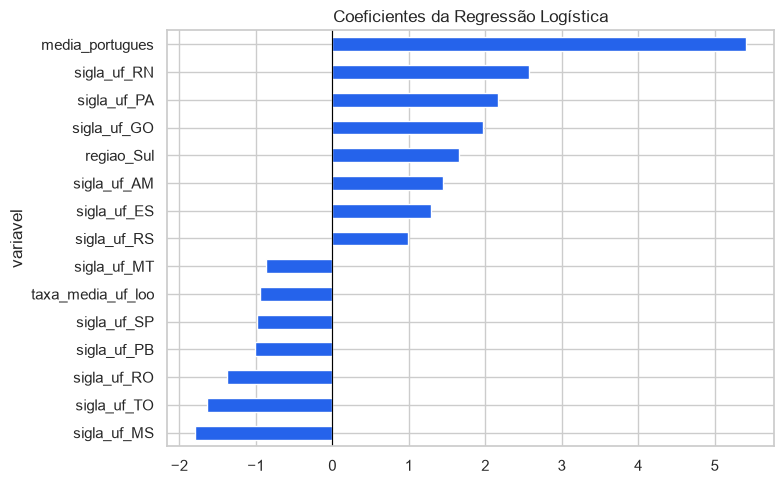

In [5]:
nomes = nomes_das_features(modelo_final)
coef = modelo_final.named_steps["modelo"].coef_[0]
importancia = pd.DataFrame({
    "variavel": nomes, "coeficiente": coef, "importancia_abs": abs(coef)
}).sort_values("importancia_abs", ascending=False)
display(importancia.head(15).round(3))
importancia.head(15).sort_values("coeficiente").plot.barh(
    x="variavel", y="coeficiente", figsize=(8, 5),
    legend=False, color="#2563eb"
)
plt.axvline(0, color="black", linewidth=.8)
plt.title("Coeficientes da Regressão Logística")
plt.tight_layout()
plt.show()

## Persistência dos artefatos

O modelo e as métricas são salvos para o notebook de aplicação. A classe positiva é atingiu a meta; risco educacional é 1 - prob_atingir_meta.

In [6]:
reports = ROOT / "reports"
reports.mkdir(exist_ok=True)
joblib.dump(modelo_final, reports / "modelo_final.joblib")
comparacao.round(6).to_csv(reports / "comparacao_modelos.csv", index=False)
card = {
    "unidade_analise": "municipio-ano-rede municipal",
    "alvo": "proxy: atingiu a meta municipal de 2025",
    "features": FEATURES,
    "treino": {"ano": 2023, "n": int(len(treino))},
    "teste": {"ano": 2024, "n": int(len(teste))},
    "melhores_parametros": busca.best_params_,
    "metricas_holdout": {
        k: round(float(v), 4) for k, v in metricas_finais.items()
        if k != "modelo"
    },
    "limitacao": (
        "indicadores contemporaneos; classificacao/nowcast municipal, "
        "nao previsao individual ou causal"
    ),
}
(reports / "model_card.json").write_text(
    json.dumps(card, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Artefatos salvos em", reports)

Artefatos salvos em C:\Development\1IAST-Fase3\reports
